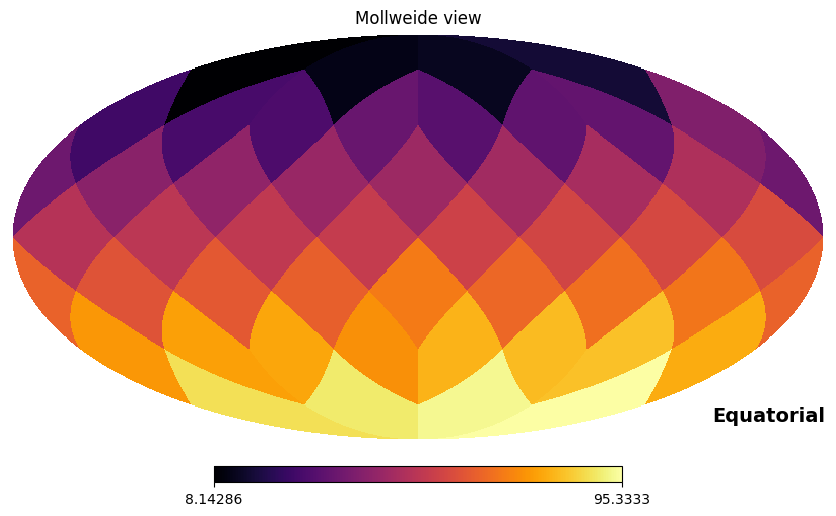

In [2]:
import numpy as np
import healpy as hp

# Create a 10x10 image array
image_array = np.arange(10 * 10).reshape(10, 10)

# Define the spherical coordinates
theta = np.linspace(0, np.pi, num=image_array.shape[0],endpoint=False)
phi = np.linspace(-np.pi, np.pi, num=image_array.shape[1], endpoint=False)  # Fix here

# Set angular resolution
nside = 2

# Create empty HEALPix map and pixel count array
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)

# Loop over theta and phi
for i in range(len(theta)):
    for j in range(len(phi)):
        # Convert spherical coordinates to HEALPix pixel index
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        
        # Accumulate values and increment pixel count
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

# Avoid division by zero
pixel_counts[pixel_counts == 0] = 1

# Average and assign to HEALPix
healpix_map /= pixel_counts
%
# Display the HEALPix map
hp.mollview(healpix_map, cmap="inferno", xsize=800, coord="C", flip="geo")
